# Sleepy Spelman Students

### An Exploratory Data Analysis of Sleep, Academic Load, and Stress Among Spelman Students

### Key Question: Does sleep appear to be associated with stress? 

**Author:** Imani Niccole Candler

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Date:** September 1, 2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the csv

df = pd.read_csv("../data/spelman_students_sleep.csv") # ../ says go up one folder, then go into data
df.head() # outputs the first 5 rows in the csv file

,Timestamp,Student Number,What is your age?,What is your classification?,What is your total credit hours this semester?,What is your degree path?,What is your living arrangement?,Do you have a consistent bedtime routine?,"On average, how many hours of sleep do you get each night?",How often (0-7 days/week) do you prioritize sleep over studying or social activities?,What is the primary reason you lose sleep?,"If you have experienced sleep deprivation, how does it affect other areas of your life (self-care, socializing with friends or family, etc.) ?",What is your current stress level?,How do you manage your stress level?
0,11/10/2025 17:21:33,1,20+,Senior,20+,Bachelor of Arts (BA),Off-Campus,Yes,7,5,Socializing,NaN,3,Yoga
1,11/10/2025 17:22:12,2,20+,Senior,20+,Bachelor of Arts (BA),On-Campus,No,4,2,Studying/Homework,it causes me to have frequent headaches,5,"honestly I dont, but ig talking to my friends ..."
2,11/10/2025 17:24:05,3,19,Sophomore,20+,Bachelor of Arts (BA),On-Campus,Yes,7,6,Studying/Homework,NaN,5,By sleeping or enjoying things that’s I like s...
3,11/10/2025 17:28:59,4,19,Sophomore,17 - 19,Bachelor of Science (BS),On-Campus,No,4,5,Studying/Homework,I was so angry and rude,5,"I don’t, it’s not enough time in the day"
4,11/10/2025 17:31:13,5,20+,Senior,17 - 19,Bachelor of Science (BS),On-Campus,No,6,2,Studying/Homework,"Self care, motivation, focus",4,"Doing things I enjoy, watching tv, going on va..."


# Understanding The Data

### First real analytics step!

In [12]:
# prints number of participants, number of columns
df.shape

# summary of DataFrame, information about columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 14 columns):
 #   Column                                                                                                                                          Non-Null Count  Dtype
---  ------                                                                                                                                          --------------  -----
 0   Timestamp                                                                                                                                       18 non-null     str  
 1   Student Number                                                                                                                                  18 non-null     int64
 2   What is your age?                                                                                                                               18 non-null     str  
 3   What is your classification?                    

In [13]:
# returns descriptive stats
df.describe()

# returns DF of boolean values. missing values (T) & non-missing values (F)
df.isnull().sum()

Timestamp                                                                                                                                         0
Student Number                                                                                                                                    0
What is your age?                                                                                                                                 0
What is your classification?                                                                                                                      0
What is your total credit hours this semester?                                                                                                    0
What is your degree path?                                                                                                                         0
What is your living arrangement?                                                                                

# Clean the Data

In [14]:
# returns the columns of DF, renaming columns
df = df.rename(columns= {
    "What is your age?": "Age",
    "What is your classification?": "Classification",
    "What is your total credit hours this semester?": "Credit_Hours",
    "What is your degree path?": "Degree",
    "What is your living arrangement?": "Living_Arrangement",
    "Do you have a consistent bedtime routine?": "Bedtime_Routine",
    "On average, how many hours of sleep do you get each night? ": "Sleep_Hours",
    "How often (0-7 days/week) do you prioritize sleep over studying or social activities?": "Prioritize_Sleep",
    "What is the primary reason you lose sleep?": "Lose_Sleep",
    "If you have experienced sleep deprivation, how does it affect other areas of your life (self-care, socializing with friends or family, etc.) ?": "Sleep_Deprivation",
    "What is your current stress level?": "Stress_Level",
    "How do you manage your stress level?": "Manage_Stress"
})

### Hours of Sleep Stats

In [15]:
# Sleep_Hours Mean
df["Sleep_Hours"].mean()

np.float64(6.222222222222222)

In [16]:
# Sleep_Hours Median
df["Sleep_Hours"].median()

np.float64(6.0)

In [17]:
# Sleep_Hours Mode
df["Sleep_Hours"].mode()

0    6
Name: Sleep_Hours, dtype: int64

In [18]:
# Sleep_Hours Range
df["Sleep_Hours"].max() - df["Sleep_Hours"].min()

np.int64(5)

In [19]:
Q1 = df["Sleep_Hours"].quantile(0.25)
Q3 =  df["Sleep_Hours"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1, "hours")
print("Q3:", Q3, "hours")
print("IQR:", IQR, "hours")

Q1: 5.25 hours
Q3: 7.0 hours
IQR: 1.75 hours


### Stress Level Stats

In [20]:
# Stress_Level Mean
df["Stress_Level"].mean()


np.float64(4.277777777777778)

In [21]:
# Stress_Level Median
df["Stress_Level"].median()


np.float64(5.0)

In [22]:
# Stress_Level Mode
df["Stress_Level"].mode()


0    5
Name: Stress_Level, dtype: int64

In [23]:
# Stress_Level Range
df["Stress_Level"].max() - df["Stress_Level"].min()


np.int64(3)

In [24]:
Q1 = df["Stress_Level"].quantile(0.25)
Q3 =  df["Stress_Level"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1, "hours")
print("Q3:", Q3, "hours")
print("IQR:", IQR, "hours")

Q1: 4.0 hours
Q3: 5.0 hours
IQR: 1.0 hours


# First Visualization!

### Sleep distribution

**Description:** 
Histogram describes the hours of sleep reported by a certain number of students.
The highest sleep distribution is 6 hours, with seven students accounted for.

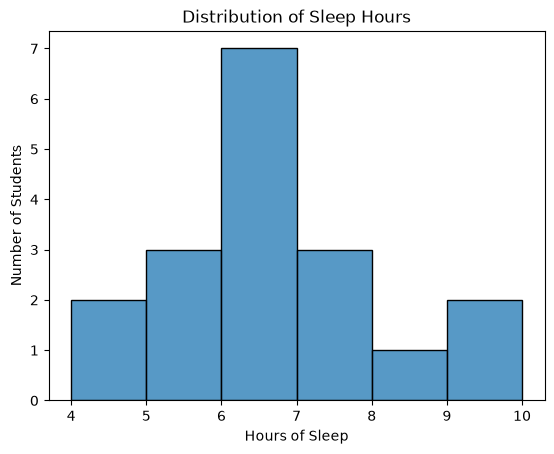

In [26]:
sns.histplot(data=df, x="Sleep_Hours", bins=range(4,11))

plt.title("Distribution of Sleep Hours")
plt.xlabel("Hours of Sleep")
plt.ylabel("Number of Students")

plt.show()

### Create the boxplot

**Description:**
The boxplot showcases the minimum and maximum hours and sleep (whiskers) and the Interquartile Range. The min is 4 hours and the max is 9 hours. Q1 is 5.25 hours and Q3 is 7 hours. Q2 is roughly 6 hours.

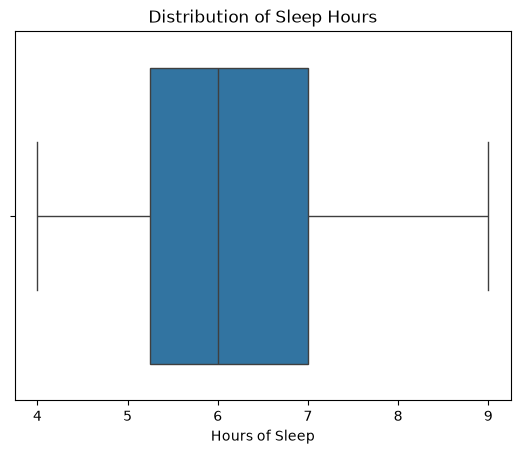

In [25]:
sns.boxplot(data=df, x="Sleep_Hours")

plt.title("Distribution of Sleep Hours")
plt.xlabel("Hours of Sleep")

plt.show()

### Stress Distribution

**Description:**
The countplot describes the stress level (1-5) of Spelman students. Note that no one selected "1," or low, as their current stress level.
Out of 18 students who were surveyed, 10 students ranked their current stress level a "5." The least-ranked stress level was "2" with 1 student.

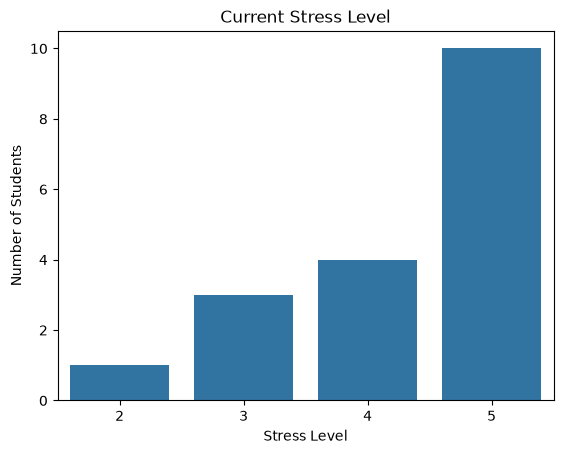

In [26]:
sns.countplot(data=df, x="Stress_Level")

plt.title("Current Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

plt.show()

# Does sleep appear to be associated with stress?

### Create a scatterplot

**Description:**
The scatterplot showcasing the correlation between hours of sleep and stress level was quite surprising. As shown, one variable does not necessarily cause the other. For example, more sleep does not equate to low stress levels. A great example of this is focusing on the two students who ranked their average hours of sleep as 9 hours. For one student, their stress level was at a "2." For the other student, their stress level was at a "5."

In [27]:
# finding duplicates in our stats

duplicates = (
    df.groupby(["Sleep_Hours", "Stress_Level"])
    .size()
    .reset_index(name="Student_Count")
    .query("Student_Count > 1")
    .sort_values("Student_Count", ascending=False)
)

print(duplicates)

   Sleep_Hours  Stress_Level  Student_Count
4            6             4              3
5            6             5              3
0            4             5              2
2            5             5              2
6            7             3              2


### Breaking down the singles and duplicates
~ Three students have a Sleep = 6 and Stress = 4  
~ Three students have a Sleep = 6 and Stress = 5  
~ Two students have a Sleep = 4 and Stress = 5  
~ Two students have a Sleep = 5 and Stress = 5  
~ Two students have a Sleep = 7 and Stress = 3  
~ One student has a Sleep = 7 and Stress = 5  
~ One student has a Sleep = 8 and Stress = 5  
~ One student has a Sleep = 9 and Stress = 5  
~ One student has a Sleep = 5 and Stress = 4  
~ One student has a Sleep = 6 and Stress = 3  
~ One student has a Sleep = 9 and Stress = 2



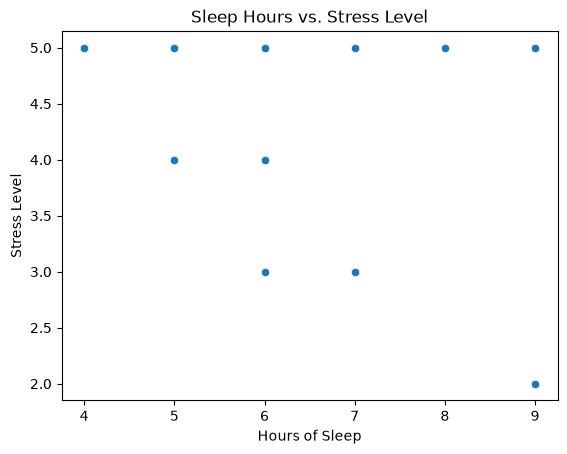

In [ ]:
sns.scatterplot(
    data=df,
    x= "Sleep_Hours",
    y= "Stress_Level"
)

plt.title("Sleep Hours vs. Stress Level")
plt.xlabel("Hours of Sleep")
plt.ylabel("Stress Level")

plt.show()

In [28]:
df["Sleep_Hours"].corr(df["Stress_Level"])

np.float64(-0.3891635433019)

### Do students who have heavier course loads report less sleep?

**Description:**
This graph groups the responses based on credit hours and hours of sleep, then calculates the mean across groups. The average reported sleep varied across credit-hour groups, with students taking 12-16 credit hours reporting the highest average sleep and students taking 17-19 cred hours reporting the lowest. Because the sample size is small and credit hours were collected categorically, these takeaways should be interpreted as descriptive rather than causal.  

It isn't accurate to state that course loads cause more or less sleep. For some students, incorporating consistent bedtime routines help with sleep intake. It all boils down to time management and scheduling. 

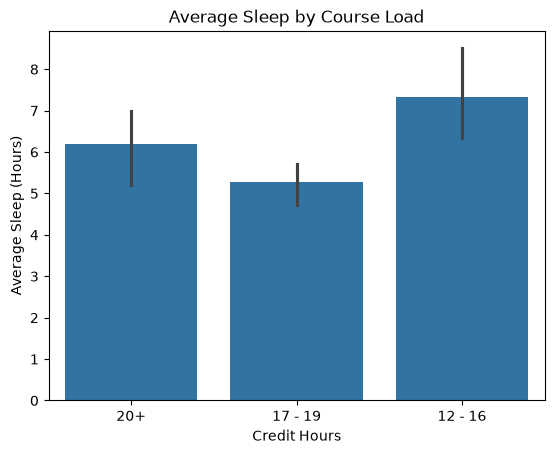

In [29]:
df.groupby("Credit_Hours")["Sleep_Hours"].mean()

sns.barplot(
    data=df,
    x = "Credit_Hours",
    y = "Sleep_Hours"
)

plt.title("Average Sleep by Course Load")
plt.xlabel("Credit Hours")
plt.ylabel("Average Sleep (Hours)")

plt.show()

# ------------------------------------------------------------------------------------------
# How Sleep Deprivation Affects Spelman Students

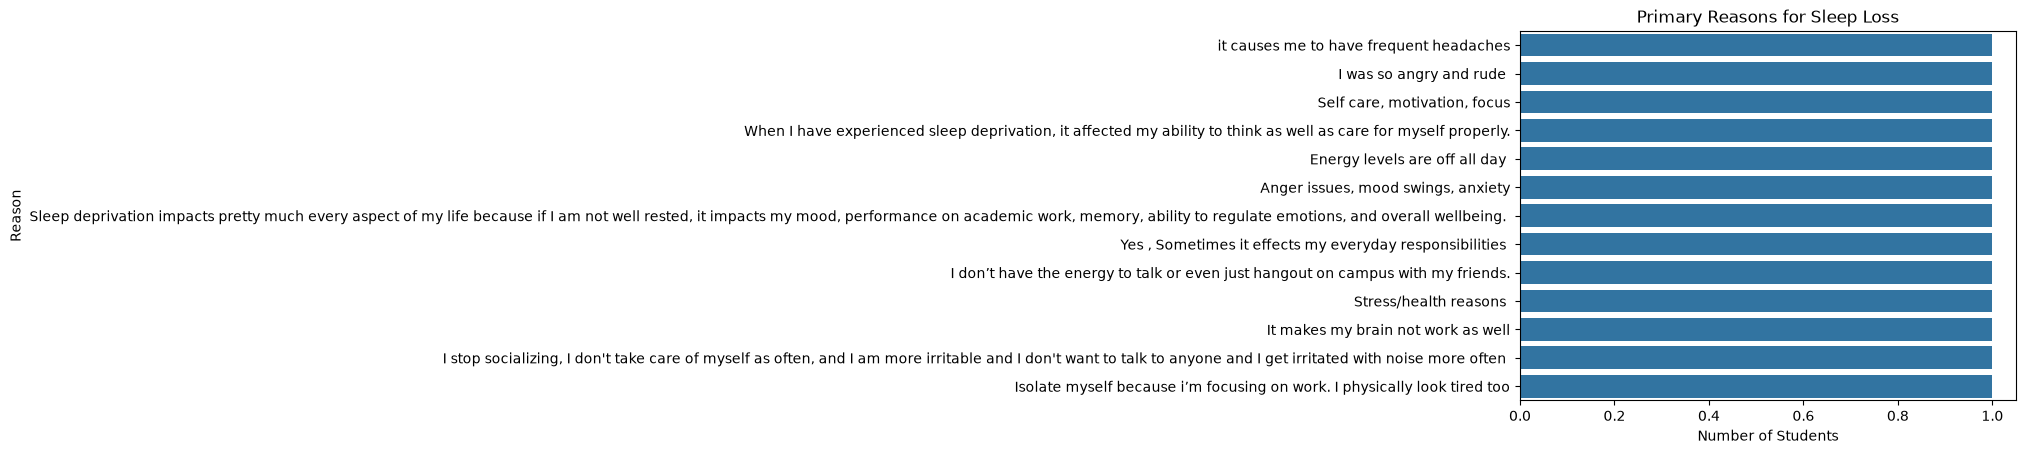

In [30]:
df["Sleep_Deprivation"].value_counts()

sns.countplot(
    data=df,
    y = "Sleep_Deprivation",
    order = df["Sleep_Deprivation"].value_counts().index
)

plt.title("Primary Reasons for Sleep Loss")
plt.xlabel("Number of Students")
plt.ylabel("Reason")

plt.show()

### Reoccurring Themes
**Physical**  
~ Headaches    
~ Fatigue  

**Academic**  
~ Difficulty focusing  
~ Motivation  
~ Academic performance  

**Emotional**  
~ Irritability  
~ Mood changes  

**Personal/Social**  
~ Reduced self-care  
~ Reduced socializing  

These open-ended responses show that sleep deprivation goes beyond feeling tired. Students who have experienced sleep deprivation mention its effects on mood, physical well-being, self-care, and academic responsibilities.

# ------------------------------------------------------------------------------------------
### Bedtime Routines

**Description:**
This boxplot showcases the relationship between hours of sleep and whether or not students have a bedtime routine. Here, it makes sense that students who do have a consistent bedtime routine, report more hours of sleep (between 6 and 7 hours), compared to students who do not have a bedtime routine. These students report between 5 and 6 hours. Could it be said that students who incorporate a bedtime routine in their schedules prioritize sleep over those who do not have a bedtime routine?

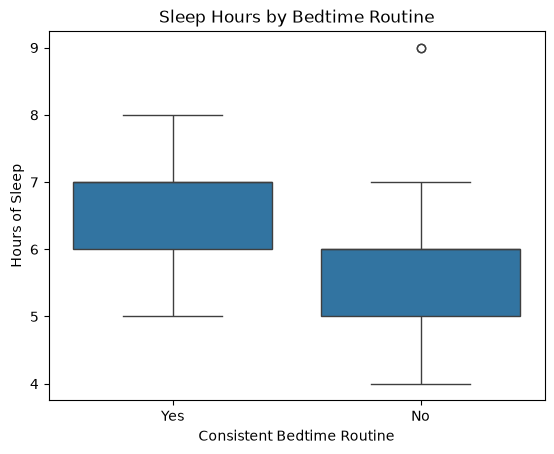

In [35]:
df.groupby("Bedtime_Routine")["Sleep_Hours"].mean()

sns.boxplot(
    data=df,
    x = "Bedtime_Routine",
    y = "Sleep_Hours"
)

plt.title("Sleep Hours by Bedtime Routine")
plt.xlabel("Consistent Bedtime Routine")
plt.ylabel("Hours of Sleep")

plt.show()

### Correlation between Sleep, Sleep Prioritization, and Stress Level

**Description:**
This was my first time interpreting a correlation matrix heatmap and it makes sense! In this matrix, average sleep intake and sleep prioritization have the highest correlation (0.39). To me, this makes perfect sense because if a consistent sleep schedule is deemed important, then, of course, the average sleep intake will be high. The inverse is true too. The second highest correlation is sleep prioritization and stress level (0.076). For some students, making sure sleep is prioritized above other responsibilities help manages their stress levels. For other students, this isn't the case. Lastly, average sleep intake and stress levels had the lowest correlation (-0.39).Unlike the first relationship, there's many factors that may cause high stress levels and low sleep intake. Increasing sleep intake does not always alleviate stress levels. High stress levels doesn't always align with low sleep intake. 

In [40]:
# excluded age from correlation analysis because the survey collected age categorically (20+) rather than an exact numerical value
# ALSO, correlating sleep and stress is useful exploratory analysis, however, don't phrase it like prioritizing sleep causes lower stress

numeric_columns = [
    "Sleep_Hours",
    "Prioritize_Sleep",
    "Stress_Level"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Sleep_Hours,Prioritize_Sleep,Stress_Level
Sleep_Hours,1.000000,0.357137,-0.389164
Prioritize_Sleep,0.357137,1.000000,0.075683
Stress_Level,-0.389164,0.075683,1.000000


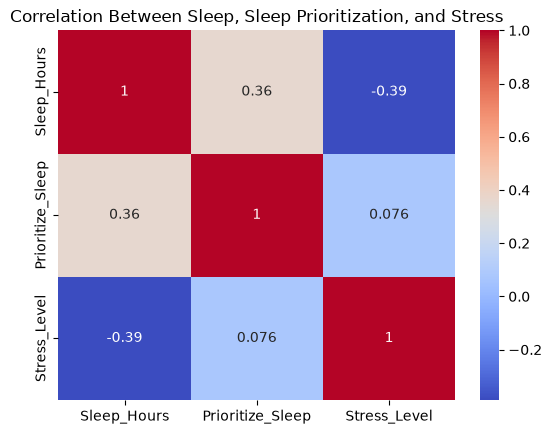

In [41]:
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Sleep, Sleep Prioritization, and Stress")

plt.show()

# ------------------------------------------------------------------------------------------
# Key Question: Does sleep appear to be associated with stress? 

### Key Findings

### Finding 1 - Sleep
Across the 18 Spelman students, participants reported an average of 6.2 hours of sleep per night, 6 hours with being the median and mode. The minimum average hours of sleep was 4 hours and the maximum average hours of sleep was 9 hours. 

### Finding 2 - Sleep & Stress
Sleep and stress showed a moderate negative correlation (r = -0.39), meaning students who reported more sleep tended to report lower stress levels. However, the relationship was not strong enough to suggest that sleep explains the difference in stress. Because this observational survey only had 18 participants, the results should not be interpreted as evidence that increased sleep causes lower stress. 


# ------------------------------------------------------------------------------------------
# Limitations
~ The survey only includes 18 Spelman students.  
~ The sample may not represent the greater Spelman College student population.  
~ The survey captures responses at one point in time (November 2025).  
~ Age and credit hours were collected categorically rather than as exact numerical values.

# ------------------------------------------------------------------------------------------
# Tip!

### Don’t equate correlation with causation!

**Correlation:** Two variables moving together. No explanation about why!  
**Causation:** The change in one variable directly causes a change in another. 